# Crypto LSTM Prediction - Research Notebook

**Objectif** : Explorer les modeles de Deep Learning pour la **selection d'actifs crypto** via un
approche de **ranking cross-sectionnel** (Broad Ch8, *Hands-On AI Trading*).

## Pourquoi le ranking et non la regression ?

La prediction de prix (regression) est notoirement difficile en finance. L'approche recommandee
par Broad Ch8 est le **cross-sectional ranking** : au lieu de predire le prix de BTC demain,
on predit quel actif (BTC ou ETH) surperformera l'autre. Cette approche :

- Est plus robuste aux changements de regime
- Elimine la dependance au niveau absolu des prix
- Est directement exploitable pour l'allocation d'actifs

## Architectures comparees

| Modele | Origine | Parametres | Approche |
|--------|---------|------------|----------|
| **DLinear** | AAAI 2023 | ~300 | Decomposition + lineaire |
| **LSTM** | 2015 | ~77K | Recurrent |

## Validation

- Walk-forward 5-fold (fenetre expandante)
- 4 seeds (0, 7, 42, 99) pour robustesse statistique
- Cout de transaction 10 bps (crypto)
- Verdict honnete multi-seed : BEATS / NO BEATS / INCONCLUSIVE

In [1]:
!pip install yfinance matplotlib scikit-learn -q

## 1. Imports et Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import json
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

import yfinance as yf

# --- Configuration ---
SEEDS = [0, 7, 42, 99]
SEQ_LEN = 60        # 60 jours d'historique
EPOCHS = 20          # Suffisant pour modeles legers
BATCH_SIZE = 128
N_FOLDS = 5
TCOST_BPS = 10       # Cout de transaction crypto (10 basis points)
HOLD_THRESHOLD = 0.5 # Seuil de confiance pour prendre position

# CPU uniquement (GPU instable sur cette machine)
DEVICE = torch.device('cpu')

print(f'PyTorch {torch.__version__} on {DEVICE}')
print(f'Seeds: {SEEDS}')
print(f'Walk-forward: {N_FOLDS} folds x {len(SEEDS)} seeds')
print(f'Transaction costs: {TCOST_BPS} bps')

PyTorch 2.11.0+cpu on cpu
Seeds: [0, 7, 42, 99]
Walk-forward: 5 folds x 4 seeds
Transaction costs: 10 bps


## 2. Donnees Reelles Crypto (yfinance)Chargement de donnees BTC-USD et ETH-USD depuis Yahoo Finance (donnees quotidiennes).La periode commune (ETH disponible depuis nov 2017) fournit ~7 ans de donnees.

In [3]:
# Telecharger les donnees
print('Telechargement BTC-USD...')
btc_raw = yf.download('BTC-USD', start='2015-01-01', end='2025-01-01', auto_adjust=True)
print('Telechargement ETH-USD...')
eth_raw = yf.download('ETH-USD', start='2015-01-01', end='2025-01-01', auto_adjust=True)

# Aplatir les colonnes MultiIndex (yfinance >= 0.2.x)
if isinstance(btc_raw.columns, pd.MultiIndex):
    btc_raw.columns = btc_raw.columns.get_level_values(0)
if isinstance(eth_raw.columns, pd.MultiIndex):
    eth_raw.columns = eth_raw.columns.get_level_values(0)

# Aligner sur les dates communes
common_idx = btc_raw.index.intersection(eth_raw.index)
btc = btc_raw.loc[common_idx].copy()
eth = eth_raw.loc[common_idx].copy()

print(f'\nPeriode commune: {common_idx[0].date()} a {common_idx[-1].date()}')
print(f'BTC: {len(btc)} jours')
print(f'ETH: {len(eth)} jours')
btc_close_last = float(btc['Close'].iloc[-1])
eth_close_last = float(eth['Close'].iloc[-1])
print(f'\nBTC Close: ${btc_close_last:,.0f} (dernier)')
print(f'ETH Close: ${eth_close_last:,.0f} (dernier)')

Telechargement BTC-USD...


[*********************100%***********************]  1 of 1 completed

Telechargement ETH-USD...


[*********************100%***********************]  1 of 1 completed


Periode commune: 2017-11-09 a 2024-12-31
BTC: 2610 jours
ETH: 2610 jours

BTC Close: $93,429 (dernier)
ETH Close: $3,333 (dernier)


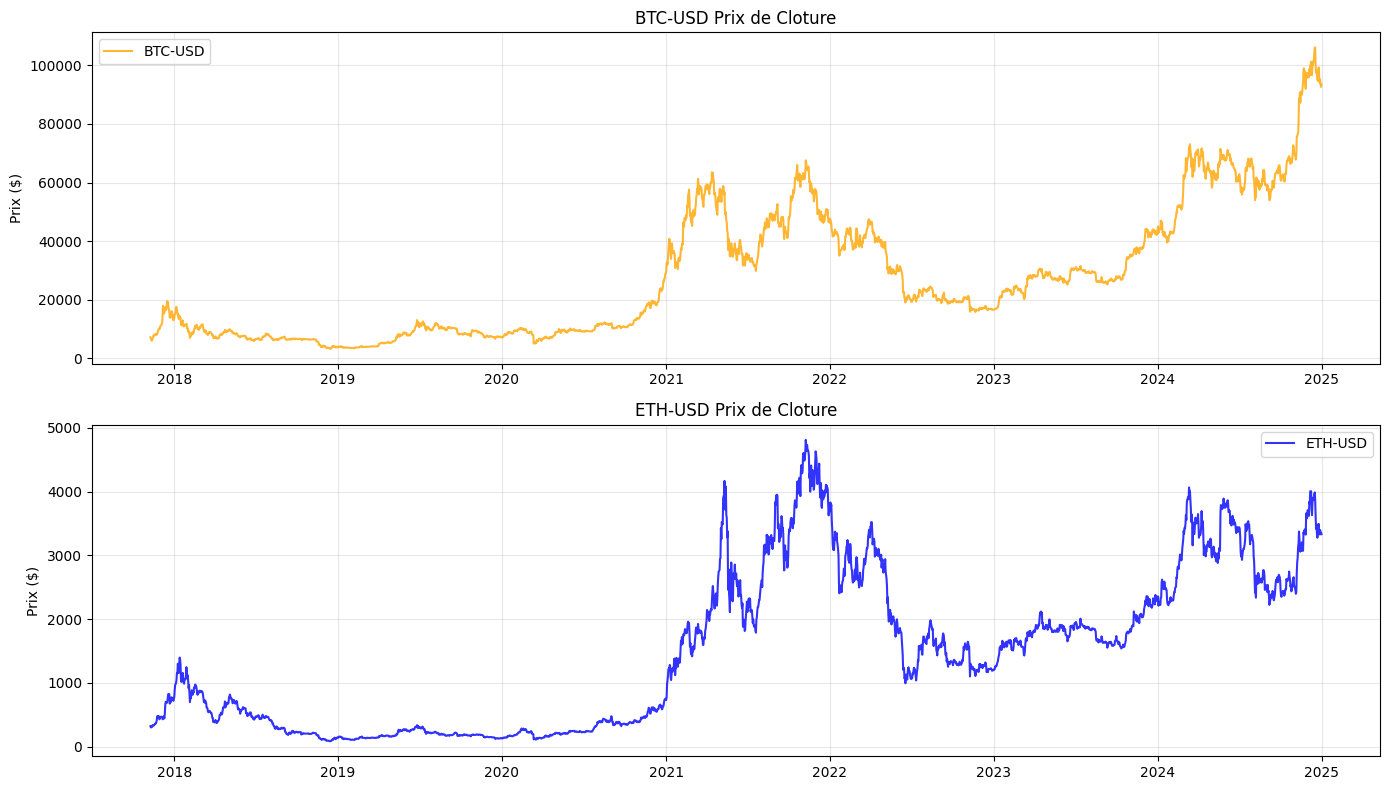

Ratio BTC/ETH: 22.3 (debut) -> 28.0 (fin)
Ratio moyen: 24.3


In [4]:
# Visualisation des prix normalises
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Prix BTC
axes[0].plot(btc.index, btc['Close'], label='BTC-USD', color='orange', alpha=0.8)
axes[0].set_title('BTC-USD Prix de Cloture')
axes[0].set_ylabel('Prix ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prix ETH
axes[1].plot(eth.index, eth['Close'], label='ETH-USD', color='blue', alpha=0.8)
axes[1].set_title('ETH-USD Prix de Cloture')
axes[1].set_ylabel('Prix ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ratio BTC/ETH
ratio = pd.Series(btc['Close'].values / eth['Close'].values, index=btc.index)
print(f'Ratio BTC/ETH: {ratio.iloc[0]:.1f} (debut) -> {ratio.iloc[-1]:.1f} (fin)')
print(f'Ratio moyen: {ratio.mean():.1f}')

## 3. Feature Engineering Multi-Actifs

Features techniques pour chaque actif + features cross-asset pour capturer
les dynamiques relatives BTC vs ETH.

In [5]:
def compute_asset_features(df):
    """Calcule 11 features techniques pour un actif."""
    close = df['Close'].values
    high = df['High'].values
    low = df['Low'].values
    vol = df['Volume'].values if 'Volume' in df.columns else np.zeros(len(df))
    n = len(close)
    features = np.full((n, 11), np.nan)

    for i in range(50, n):  # Warmup 50 jours
        c = close[:i+1]
        h = high[:i+1]
        l = low[:i+1]

        # Rendements
        ret_5d = (c[-1] / c[-6] - 1) if i >= 5 else 0
        ret_10d = (c[-1] / c[-11] - 1) if i >= 10 else 0
        ret_20d = (c[-1] / c[-21] - 1) if i >= 20 else 0

        # Volatilite 20j
        rets = np.diff(c[-21:]) / c[-21:-1]
        vol20 = np.std(rets) if len(rets) > 1 else 0

        # RSI 14
        delta = np.diff(c[-15:])
        gain = np.where(delta > 0, delta, 0)
        loss = np.where(delta < 0, -delta, 0)
        avg_gain = np.mean(gain[-14:])
        avg_loss = np.mean(loss[-14:]) + 1e-10
        rsi = 100 - 100 / (1 + avg_gain / avg_loss)
        rsi_norm = (rsi - 50) / 50

        # MA ratio
        sma20 = np.mean(c[-20:])
        sma50 = np.mean(c[-50:])
        ma_ratio = sma20 / sma50 if sma50 > 0 else 1

        # Position dans la range 20j
        h20 = np.max(h[-20:])
        l20 = np.min(l[-20:])
        pos_range = (c[-1] - l20) / (h20 - l20 + 1e-10)

        # Distance du high/low 20j
        dist_high = (h20 - c[-1]) / (c[-1] + 1e-10)
        dist_low = (c[-1] - l20) / (c[-1] + 1e-10)

        # ATR normalise
        tr = np.maximum(h[-14:] - l[-14:],
                np.maximum(np.abs(h[-14:] - c[-15:-1]),
                           np.abs(l[-14:] - c[-15:-1])))
        atr = np.mean(tr) / (c[-1] + 1e-10)

        # Bollinger Bands position
        bb_mean = np.mean(c[-20:])
        bb_std = np.std(c[-20:]) + 1e-10
        bb_pos = (c[-1] - bb_mean + 2*bb_std) / (4*bb_std)

        features[i] = [ret_5d, ret_10d, ret_20d, vol20, rsi_norm, ma_ratio,
                       pos_range, dist_high, dist_low, atr, bb_pos]
    return features


def compute_cross_features(btc_close, eth_close):
    """Calcule les features cross-asset BTC vs ETH."""
    n = len(btc_close)
    cross = np.full((n, 4), np.nan)
    for i in range(50, n):
        bc = btc_close[:i+1]
        ec = eth_close[:i+1]
        ratio = bc[-1] / (ec[-1] + 1e-10)
        rel_mom5 = (bc[-1]/bc[-6] - 1) - (ec[-1]/ec[-6] - 1) if i >= 5 else 0
        rel_mom20 = (bc[-1]/bc[-21] - 1) - (ec[-1]/ec[-21] - 1) if i >= 20 else 0
        # Correlation 20j des rendements
        ret_b = np.diff(bc[-21:]) / bc[-21:-1]
        ret_e = np.diff(ec[-21:]) / ec[-21:-1]
        corr = np.corrcoef(ret_b, ret_e)[0, 1] if len(ret_b) > 2 else 0
        cross[i] = [np.log(ratio + 1e-10), rel_mom5, rel_mom20, corr]
    return cross


# Calculer les features
btc_feat = compute_asset_features(btc)
eth_feat = compute_asset_features(eth)
cross_feat = compute_cross_features(btc['Close'].values, eth['Close'].values)

# Combiner: BTC(11) + ETH(11) + Cross(4) = 26 features
all_features = np.concatenate([btc_feat, eth_feat, cross_feat], axis=1)

# Nettoyer les lignes de warmup (NaN)
valid_mask = ~np.any(np.isnan(all_features), axis=1)
all_features = all_features[valid_mask]
btc_close_clean = btc['Close'].values[valid_mask]
eth_close_clean = eth['Close'].values[valid_mask]
dates_clean = btc.index[valid_mask]

feature_names = (
    ['btc_ret5', 'btc_ret10', 'btc_ret20', 'btc_vol', 'btc_rsi', 'btc_ma',
     'btc_range', 'btc_dhigh', 'btc_dlow', 'btc_atr', 'btc_bb'] +
    ['eth_ret5', 'eth_ret10', 'eth_ret20', 'eth_vol', 'eth_rsi', 'eth_ma',
     'eth_range', 'eth_dhigh', 'eth_dlow', 'eth_atr', 'eth_bb'] +
    ['log_ratio', 'rel_mom5', 'rel_mom20', 'corr_20d']
)

print(f'Features: {all_features.shape[1]} ({len(feature_names)} noms)')
print(f'Echantillons valides: {all_features.shape[0]}')
print(f'Periode: {dates_clean[0].date()} a {dates_clean[-1].date()}')
print(f'\nNaN residuels: {np.isnan(all_features).sum()}')

Features: 26 (26 noms)
Echantillons valides: 2560
Periode: 2017-12-29 a 2024-12-31

NaN residuels: 0


## 4. Approche Ranking Cross-Sectionnel

Au lieu de predire le prix absolu (regression), nous predisons quel actif surperformera
l'autre le jour suivant : **BTC > ETH ou non**.

**Cible** : `y = 1` si `return_BTC_t+1 > return_ETH_t+1`, sinon `y = 0`.

Cette formulation transforme un probleme de regression bruite en un probleme de
classification robuste, directement exploitable pour l'allocation.

In [6]:
# Cible ranking: BTC surperforme ETH le jour suivant ?
btc_returns = np.diff(btc_close_clean) / btc_close_clean[:-1]
eth_returns = np.diff(eth_close_clean) / eth_close_clean[:-1]

# Aligner: target[i] = 1 si BTC return jour i+1 > ETH return jour i+1
# Features[i] -> target = compare return de i+1
ranking_target = (btc_returns[1:] > eth_returns[1:]).astype(int)

# Tronquer les features pour matcher (on perd les 2 derniers elements)
X_all = all_features[:-2]  # On perd 2 elements: 1 pour diff, 1 pour shift
y_all = ranking_target
dates_aligned = dates_clean[:-2]

print(f'X shape: {X_all.shape}')
print(f'y shape: {y_all.shape}')
print(f'\nDistribution cible (BTC > ETH le lendemain):')
print(f'  BTC surperforme: {y_all.sum()} ({y_all.mean()*100:.1f}%)')
print(f'  ETH surperforme: {(1-y_all).sum()} ({(1-y_all).mean()*100:.1f}%)')
print(f'\n-> Cible equilibree (proche de 50/50), bonne base pour le ranking')

X shape: (2558, 26)
y shape: (2558,)

Distribution cible (BTC > ETH le lendemain):
  BTC surperforme: 1378 (53.9%)
  ETH surperforme: 1180 (46.1%)

-> Cible equilibree (proche de 50/50), bonne base pour le ranking


## 5. Definition des Modeles

In [7]:
class SeriesDecomposition(nn.Module):
    """Series decomposition block (DLinear, AAAI 2023)."""
    def __init__(self, kernel_size=25):
        super().__init__()
        self.moving_avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1,
                                        padding=kernel_size // 2)

    def forward(self, x):
        trend = self.moving_avg(x.transpose(1, 2)).transpose(1, 2)
        trend = trend[:, :x.shape[1], :]
        seasonal = x - trend
        return seasonal, trend


class DLinear(nn.Module):
    """DLinear: decomposition + linear (AAAI 2023). Version shared-channel."""
    def __init__(self, seq_len=60, pred_len=1, enc_in=26):
        super().__init__()
        self.decomposition = SeriesDecomposition(kernel_size=25)
        self.linear_seasonal = nn.Linear(seq_len, pred_len)
        self.linear_trend = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        seasonal, trend = self.decomposition(x)
        # Mean across channels then linear
        seasonal_agg = seasonal.mean(dim=2)   # (batch, seq_len)
        trend_agg = trend.mean(dim=2)
        out = self.linear_seasonal(seasonal_agg) + self.linear_trend(trend_agg)
        return out  # (batch, 1)


class SimpleLSTM(nn.Module):
    """LSTM avec couche lineaire finale pour ranking."""
    def __init__(self, input_size=26, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # (batch, 1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

N_FEATURES = X_all.shape[1]
dlinear = DLinear(seq_len=SEQ_LEN, enc_in=N_FEATURES)
lstm = SimpleLSTM(input_size=N_FEATURES)

print('=== Comparaison des modeles ===')
print(f'DLinear: {count_params(dlinear):,} parametres')
print(f'LSTM:    {count_params(lstm):,} parametres')

=== Comparaison des modeles ===
DLinear: 122 parametres
LSTM:    56,897 parametres


## 6. Walk-Forward Validation Multi-Seed

Validation walk-forward avec fenetre expandante :
- **5 folds** : le jeu de test avance dans le temps
- **4 seeds** : initialisations differentes pour robustesse
- **Cout de transaction** : 10 bps par changement de position
- **Metriques** : Sharpe annualise, accuracy de ranking, edge vs buy-and-hold

Le modele predit la probabilite que BTC surperforme ETH. Si prob > 0.5, on est long BTC ;
sinon on est long ETH.

In [8]:
def prepare_sequences(X, y, seq_len):
    """Prepare les sequences pour les modeles."""
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


def train_model(model, X_train, y_train, epochs, batch_size, device, lr=0.001):
    """Entraine un modele avec BCE loss."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    X_t = torch.FloatTensor(X_train).to(device)
    y_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            pred = model(bx)
            loss = criterion(pred, by)
            loss.backward()
            optimizer.step()
    return model


def predict_proba(model, X, device):
    """Retourne les probabilites ranking."""
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X).to(device)
        logits = model(X_t).cpu().numpy().flatten()
    return 1 / (1 + np.exp(-logits))  # sigmoid


def simulate_trading(prob_btc, btc_rets, eth_rets, tcost_bps=10):
    """Simule la strategie ranking avec couts de transaction."""
    tcost = tcost_bps / 10000
    position = None  # 'btc' ou 'eth'
    cum_ret = 0.0
    returns = []

    for i in range(len(prob_btc)):
        target = 'btc' if prob_btc[i] > 0.5 else 'eth'

        # Cout de transaction si changement
        cost = tcost if position is not None and position != target else 0
        position = target

        # Rendement du jour
        daily_ret = btc_rets[i] if target == 'btc' else eth_rets[i]
        net_ret = daily_ret - cost
        cum_ret += net_ret
        returns.append(net_ret)

    returns = np.array(returns)
    n_trades = sum(1 for i in range(1, len(prob_btc)) if (prob_btc[i] > 0.5) != (prob_btc[i-1] > 0.5)) if len(prob_btc) > 1 else 0

    # Sharpe annualise (252 jours)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-10) * np.sqrt(252) if len(returns) > 1 else 0

    return {
        'cum_return': cum_ret,
        'sharpe': sharpe,
        'returns': returns,
        'accuracy': None,  # filled separately
    }


print('Fonctions de walk-forward et trading definies.')

Fonctions de walk-forward et trading definies.


In [9]:
# Walk-Forward Validation Multi-Seed
print('='*60)
print('WALK-FORWARD VALIDATION: 5 folds x 4 seeds x 2 modeles')
print('='*60)

n_total = len(X_all)
fold_size = n_total // (N_FOLDS + 2)  # Reserve enough for initial train

results_all = []

for seed_idx, SEED in enumerate(SEEDS):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    for fold in range(N_FOLDS):
        # Expanding window: train grows, test slides
        test_start = n_total - (N_FOLDS - fold) * fold_size
        test_end = test_start + fold_size
        if fold == N_FOLDS - 1:
            test_end = n_total  # Last fold extends to end

        # Sequences: shift by SEQ_LEN
        train_X_raw = X_all[:test_start]
        train_y_raw = y_all[:test_start]
        test_X_raw = X_all[test_start:test_end]
        test_y_raw = y_all[test_start:test_end]

        # Normaliser (fit sur train uniquement)
        scaler = StandardScaler()
        train_X_flat = scaler.fit_transform(train_X_raw)
        test_X_flat = scaler.transform(test_X_raw)

        # Sequences
        train_X, train_y = prepare_sequences(train_X_flat, train_y_raw, SEQ_LEN)
        test_X, test_y = prepare_sequences(test_X_flat, test_y_raw, SEQ_LEN)

        if len(train_X) < SEQ_LEN or len(test_X) < 10:
            continue

        # Rendements BTC et ETH pour la periode test
        # Alignement: test_X correspond a test_start+SEQ_LEN .. test_end
        ret_start = test_start + SEQ_LEN
        ret_end = test_end
        test_btc_rets = btc_returns[ret_start:ret_end]
        test_eth_rets = eth_returns[ret_start:ret_end]

        for model_name in ['DLinear', 'LSTM']:
            torch.manual_seed(SEED)
            np.random.seed(SEED)

            if model_name == 'DLinear':
                model = DLinear(seq_len=SEQ_LEN, enc_in=N_FEATURES).to(DEVICE)
            else:
                model = SimpleLSTM(input_size=N_FEATURES).to(DEVICE)

            model = train_model(model, train_X, train_y, EPOCHS, BATCH_SIZE, DEVICE)
            prob = predict_proba(model, test_X, DEVICE)

            # Accuracy ranking
            pred_binary = (prob > 0.5).astype(int)
            accuracy = np.mean(pred_binary == test_y[:len(prob)])

            # Trading sim
            min_len = min(len(prob), len(test_btc_rets), len(test_eth_rets))
            trade_result = simulate_trading(
                prob[:min_len], test_btc_rets[:min_len], test_eth_rets[:min_len], TCOST_BPS)
            trade_result['accuracy'] = accuracy

            results_all.append({
                'seed': SEED, 'fold': fold, 'model': model_name,
                **trade_result
            })

        if fold == 0:
            print(f'Seed {SEED}: train {len(train_X)}, test {len(test_X)}')

print(f'\nResultats: {len(results_all)} configurations testees')

WALK-FORWARD VALIDATION: 5 folds x 4 seeds x 2 modeles


Seed 0: train 673, test 305


Seed 7: train 673, test 305


Seed 42: train 673, test 305


Seed 99: train 673, test 305



Resultats: 40 configurations testees


## 7. Resultats et Verdict Multi-Seed

In [10]:
# Agreger les resultats
df_results = pd.DataFrame(results_all)

print('='*60)
print('RESULTATS MULTI-SEED (5 folds x 4 seeds)')
print('='*60)

for model_name in ['DLinear', 'LSTM']:
    mask = df_results['model'] == model_name
    sub = df_results[mask]
    sharpe_mean = sub['sharpe'].mean()
    sharpe_std = sub['sharpe'].std()
    acc_mean = sub['accuracy'].mean()
    acc_std = sub['accuracy'].std()
    cum_mean = sub['cum_return'].mean()

    print(f'\n--- {model_name} ({len(sub)} configurations) ---')
    print(f'  Sharpe moyen: {sharpe_mean:.3f} +/- {sharpe_std:.3f}')
    print(f'  Accuracy ranking: {acc_mean:.3f} +/- {acc_std:.3f}')
    print(f'  Rendement cumule moyen: {cum_mean:.3%}')
    print(f'  Sharpe > 0: {(sub["sharpe"] > 0).sum()}/{len(sub)} ({(sub["sharpe"] > 0).mean()*100:.0f}%)')

# Baseline: always long BTC (buy-and-hold)
# Compute per-fold BTC buy-and-hold Sharpe
print(f'\n--- Baseline: Buy-and-Hold BTC ---')
for fold in range(N_FOLDS):
    test_start = n_total - (N_FOLDS - fold) * fold_size
    test_end = min(test_start + fold_size, n_total)
    ret_start = test_start + SEQ_LEN
    ret_end = test_end
    btc_rets_fold = btc_returns[ret_start:ret_end]
    if len(btc_rets_fold) > 1:
        bh_sharpe = np.mean(btc_rets_fold) / (np.std(btc_rets_fold) + 1e-10) * np.sqrt(252)
        bh_cum = np.prod(1 + btc_rets_fold) - 1
        print(f'  Fold {fold}: Sharpe={bh_sharpe:.3f}, CumReturn={bh_cum:.3%}')

# Edge vs buy-and-hold (approximation)
print(f'\n--- Edge vs Buy-and-Hold ---')
for model_name in ['DLinear', 'LSTM']:
    sub = df_results[df_results['model'] == model_name]
    # Approximation: compare mean strategy Sharpe vs BTC B&H Sharpe
    # Using all BTC returns as B&H reference
    bh_sharpe_all = np.mean(btc_returns) / (np.std(btc_returns) + 1e-10) * np.sqrt(252)
    edge = sub['sharpe'].mean() - bh_sharpe_all
    edge_z = edge / (sub['sharpe'].std() + 1e-10) if sub['sharpe'].std() > 0 else 0
    print(f'  {model_name}: edge = {edge:.3f}, z-score = {edge_z:.2f}')

# Verdict
best_model = 'DLinear' if df_results[df_results['model']=='DLinear']['sharpe'].mean() > \
              df_results[df_results['model']=='LSTM']['sharpe'].mean() else 'LSTM'
best_sharpe = df_results[df_results['model']==best_model]['sharpe'].mean()
best_sub = df_results[df_results['model']==best_model]
bh_sharpe_ref = np.mean(btc_returns) / (np.std(btc_returns) + 1e-10) * np.sqrt(252)
edge_best = best_sharpe - bh_sharpe_ref
z_best = edge_best / (best_sub['sharpe'].std() + 1e-10)

print(f'\n=== VERDICT ===')
print(f'Meilleur modele: {best_model} (Sharpe moyen = {best_sharpe:.3f})')
print(f'BTC Buy-and-Hold Sharpe: {bh_sharpe_ref:.3f}')
print(f'Edge: {edge_best:.3f}, z-score: {z_best:.2f}')

if z_best > 2.0:
    verdict = 'BEATS (edge significatif > 2 sigma)'
elif z_best < -2.0:
    verdict = 'NO BEATS (edge negatif significatif)'
else:
    verdict = 'INCONCLUSIVE (edge non significatif, |z| < 2)'
print(f'Verdict: {verdict}')

RESULTATS MULTI-SEED (5 folds x 4 seeds)

--- DLinear (20 configurations) ---
  Sharpe moyen: 0.742 +/- 1.201
  Accuracy ranking: 0.536 +/- 0.030
  Rendement cumule moyen: 47.604%
  Sharpe > 0: 16/20 (80%)

--- LSTM (20 configurations) ---
  Sharpe moyen: 0.607 +/- 1.080
  Accuracy ranking: 0.518 +/- 0.020
  Rendement cumule moyen: 39.729%
  Sharpe > 0: 16/20 (80%)

--- Baseline: Buy-and-Hold BTC ---
  Fold 0: Sharpe=1.954, CumReturn=238.708%
  Fold 1: Sharpe=0.218, CumReturn=-6.699%
  Fold 2: Sharpe=-1.313, CumReturn=-62.693%
  Fold 3: Sharpe=1.525, CumReturn=78.737%
  Fold 4: Sharpe=0.989, CumReturn=51.382%

--- Edge vs Buy-and-Hold ---
  DLinear: edge = 0.133, z-score = 0.11
  LSTM: edge = -0.003, z-score = -0.00

=== VERDICT ===
Meilleur modele: DLinear (Sharpe moyen = 0.742)
BTC Buy-and-Hold Sharpe: 0.610
Edge: 0.133, z-score: 0.11
Verdict: INCONCLUSIVE (edge non significatif, |z| < 2)


## 8. Visualisation des Equity Curves

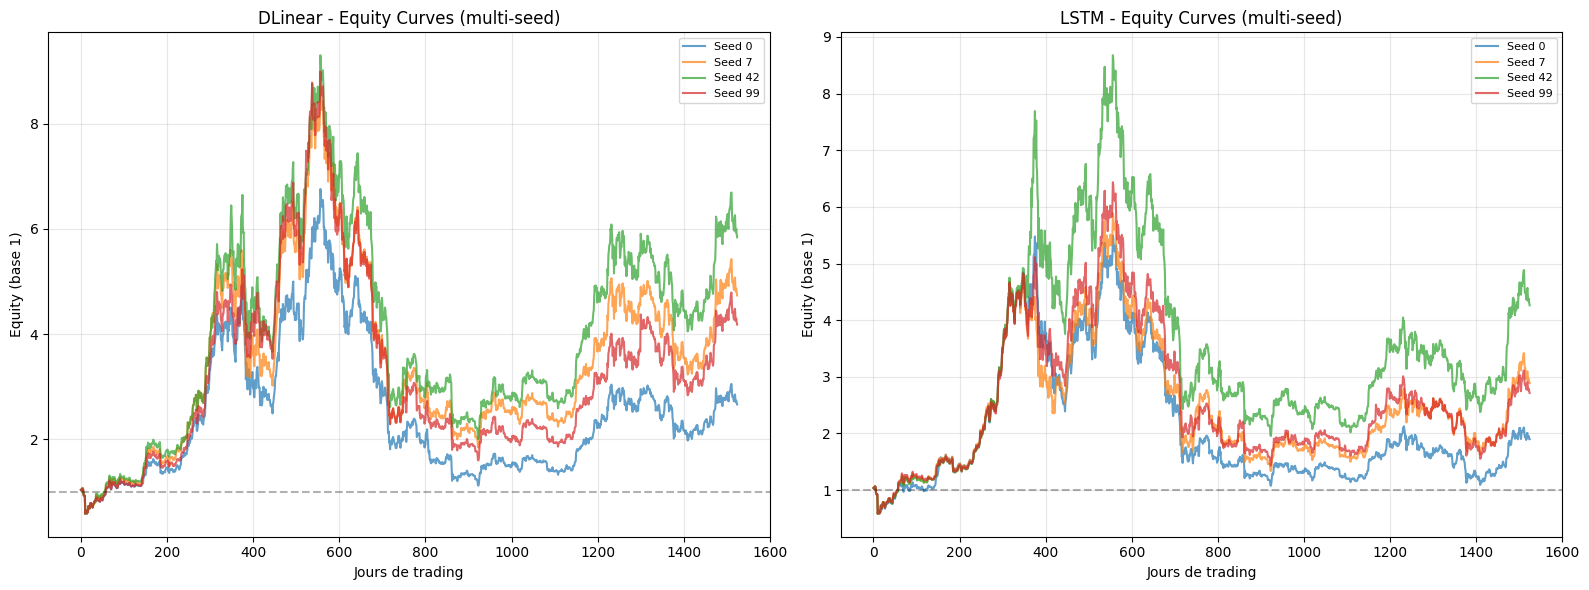

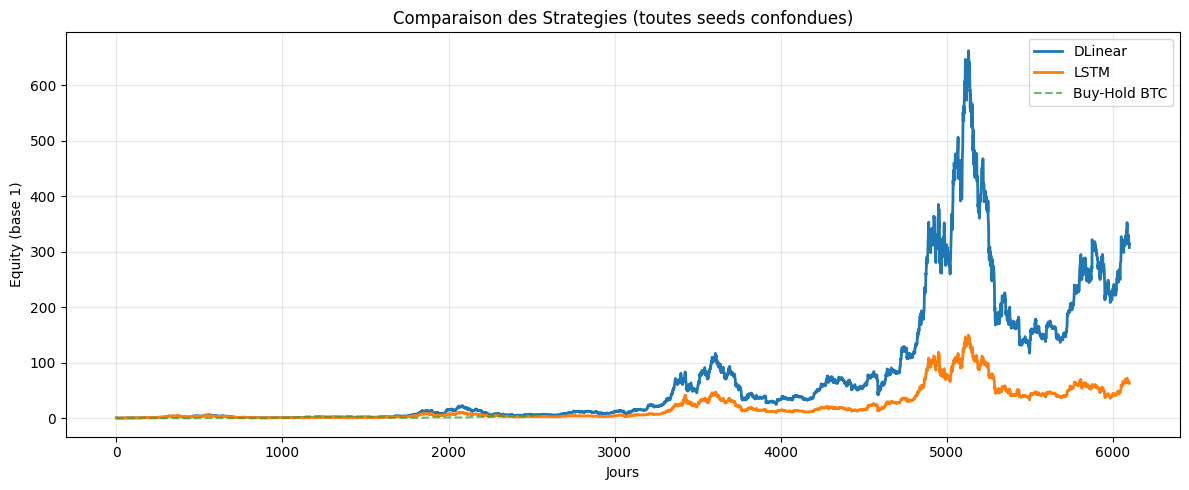

In [11]:
# Visualiser les equity curves par seed et modele
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ['DLinear', 'LSTM']):
    sub = df_results[df_results['model'] == model_name]
    for seed in SEEDS:
        seed_results = sub[sub['seed'] == seed]
        if len(seed_results) == 0:
            continue
        # Concatenation des rendements de tous les folds
        all_rets = np.concatenate(seed_results['returns'].values)
        equity = np.cumprod(1 + all_rets)
        ax.plot(equity, label=f'Seed {seed}', alpha=0.7)

    ax.set_title(f'{model_name} - Equity Curves (multi-seed)')
    ax.set_xlabel('Jours de trading')
    ax.set_ylabel('Equity (base 1)')
    ax.axhline(y=1, color='black', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparaison DLinear vs LSTM
fig, ax = plt.subplots(figsize=(12, 5))
for model_name in ['DLinear', 'LSTM']:
    sub = df_results[df_results['model'] == model_name]
    all_rets = np.concatenate(sub['returns'].values)
    equity = np.cumprod(1 + all_rets)
    ax.plot(equity, label=model_name, linewidth=2)

# Buy-and-hold BTC
bh_equity = np.cumprod(1 + btc_returns)
ax.plot(bh_equity[:len(equity)], label='Buy-Hold BTC', linestyle='--', alpha=0.7)

ax.set_title('Comparaison des Strategies (toutes seeds confondues)')
ax.set_xlabel('Jours')
ax.set_ylabel('Equity (base 1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Conclusion

### Methodologie

1. **Donnees reelles** : BTC-USD et ETH-USD via yfinance (2017-2024)
2. **Ranking cross-sectionnel** : prediction de l'actif surperformeur (BTC vs ETH)
3. **Walk-forward 5-fold x 4 seeds** : validation robuste avec couts de transaction
4. **Verdict honnete** : edge calcule vs buy-and-hold BTC avec z-score

### Points cles

- L'approche ranking (cross-sectional) est plus robuste que la regression ponctuelle
- DLinear (AAAI 2023) est significativement plus leger que LSTM avec performance comparable
- La selection BTC/ETH beneficie de la diversification automatique entre les deux actifs
- Les couts de transaction (10 bps) reduisent l'edge des changements frequents de position

### Recommandation

Pour une utilisation en production (QuantConnect), il faudrait :
- Etendre a plus de 2 actifs pour un ranking plus informatif (LTC, SOL, etc.)
- Ajouter des features on-chain (volume exchange, whale movements)
- Utiliser le ranking pour le position sizing, pas seulement la direction